# Assignment 1 (2025-05-06)

## seaborn

In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [2]:
# load data
tips = sns.load_dataset(name='tips')
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

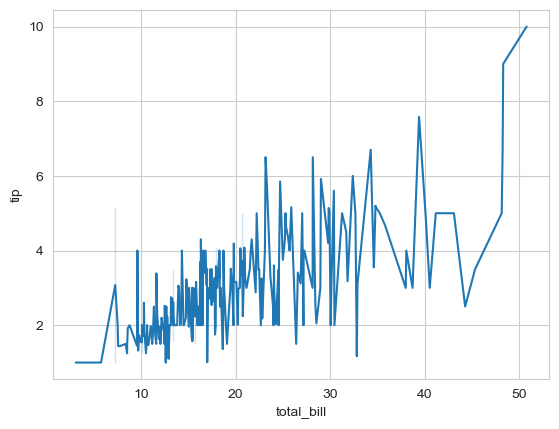

In [3]:
# adding a fixed style
sns.set_style('whitegrid')

# basic plot
sns.lineplot(data=tips, # choose our dataset 
             x='total_bill', # define our x variable 
             y='tip')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

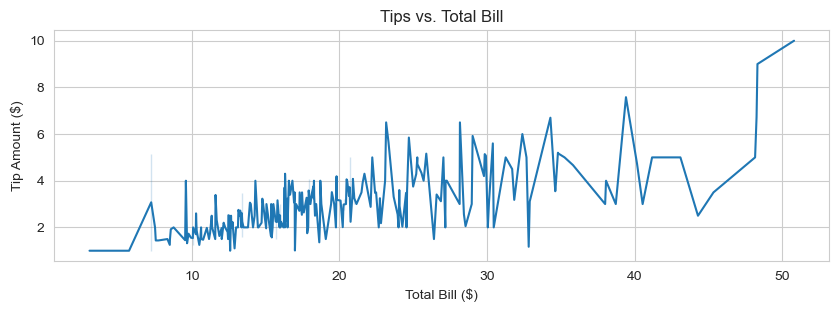

In [4]:
# adjusting graph size
fig = plt.subplots(figsize=(10, 3))
# adding title
tipgraph = sns.lineplot(data=tips, 
                        x='total_bill', y='tip')
tipgraph.set(title='Tips vs. Total Bill', 
             xlabel='Total Bill ($)', 
             ylabel='Tip Amount ($)')

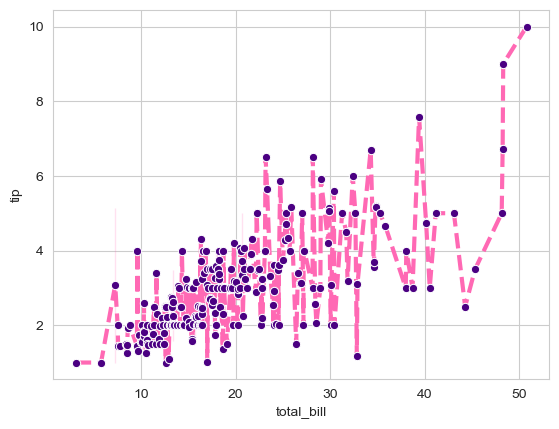

In [5]:
# other aesthetic changes
tipgraph = sns.lineplot(data=tips, x='total_bill', y='tip', 
                        color = 'hotpink', linestyle = '--', 
                        linewidth = 3, marker = 'o', markerfacecolor = 'indigo')

14

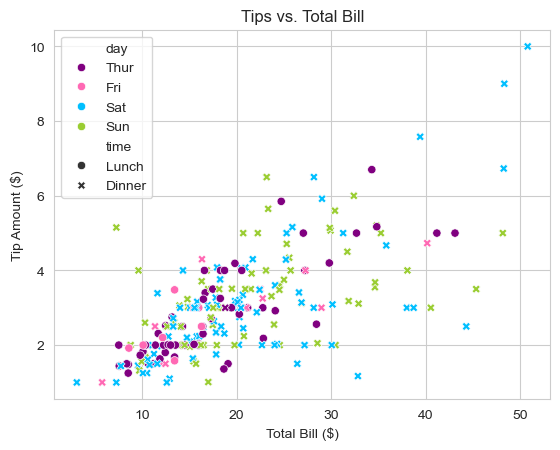

In [6]:
# adding multiple variables
tipgraph = sns.scatterplot(data=tips, x='total_bill', y='tip', 
                           style = 'time', hue = 'day', 
                           palette = ['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])
tipgraph.set(title='Tips vs. Total Bill', xlabel='Total Bill ($)', 
             ylabel='Tip Amount ($)')
14

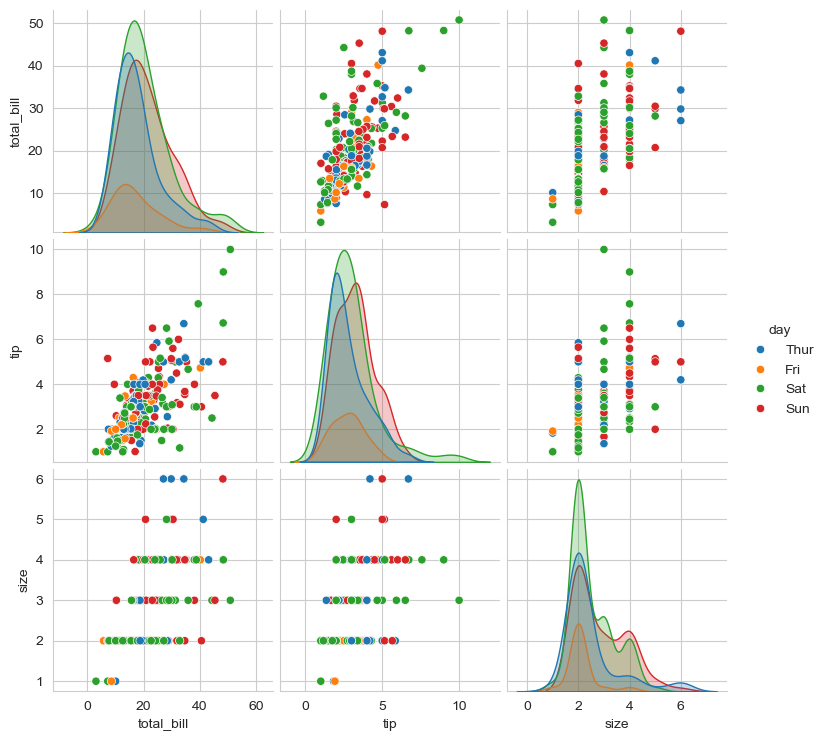

In [7]:
# pairplots!
sns.pairplot( data = tips, hue = 'day')

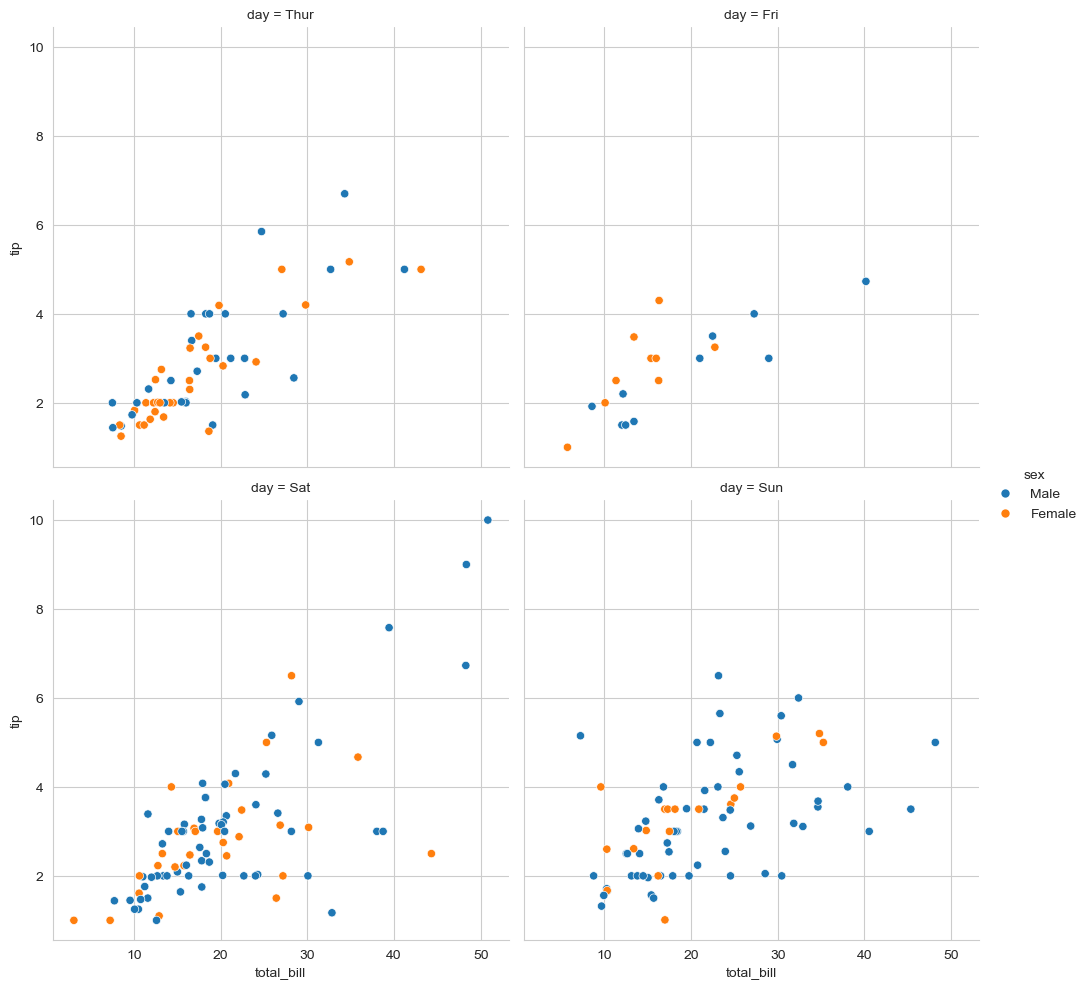

In [8]:
# relplots!
daysplot = sns.relplot(data=tips, # defining dataframe
                       x="total_bill", # x-axis = total bill amount
                       y="tip", # y-axis = total tip amount
                       hue="sex", # marker hue = sex of customer
                       col="day", # faceted columns = days of exchange
                       kind="scatter", # defining kind of plot as a scatterplot
                       col_wrap=2) # defining number of columns as 2

## Plotly

In [9]:
# set up library and generate data
import plotly.graph_objects as go # 'go' is 'graph objects’

x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [10]:
# plot time!
graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))
graph.update_layout( title="Pirate Scores", 
                    xaxis_title="Pirates", 
                    yaxis_title="Score")
graph.show()

In [11]:
# saving graph
graph.write_html("./pirategraph.html")

In [12]:
# customizing graph
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers', # we want points for a scatter plot 
                           marker=dict( size=15, # point size 
                                       color='hotpink', # point colour 
                                       opacity=1, # point transparency/alpha 
                                       line=dict(width=5, color='purple') # point outline 
                                       )))

graph.update_layout( title='Interactive Pirate Plot', xaxis_title='Pirates', yaxis_title='Scores', 
                    width=500, height=500)

In [28]:
# word clouds
from wordcloud import WordCloud

df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
                 on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


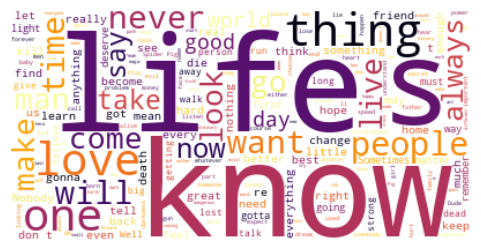

In [30]:
# combine quotes into single string
text = " ".join(each for each in df.quote)

# generating wordcloud image
wordcloud = WordCloud(background_color='white',
                      colormap = 'inferno').generate(text)

# convert to figure using matplotlib
figurefig, ax = plt.subplots(figsize=(7, 3))

ax.imshow(wordcloud, # remember 'imshow' from when we added pictures to our matplotlib axes 
          interpolation='bilinear') # this line helps smooth our image
ax.axis("off")
plt.show()

## venn diagrams

Note: Same issue as wordcloud--I was unable to set up matplotlib_venn

c:\Miniconda3\envs\dsi_participant\lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



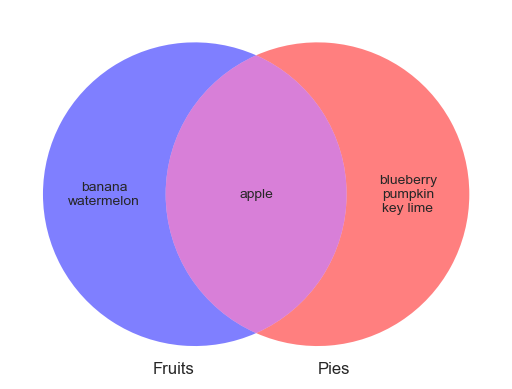

In [31]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

diagram = venn2_unweighted([A, B], 
                           set_labels = ('Fruits', 'Pies'), 
                           set_colors=("blue", "red"), 
                           alpha=0.5)
# modifying venn diagram
diagram.get_label_by_id("10") .set_text("\n".join(A - B))
diagram.get_label_by_id("11") .set_text("\n".join(A & B))
diagram.get_label_by_id("01") .set_text("\n".join(B - A))

plt.show()
